<a href="https://colab.research.google.com/github/pranaychowdary765/-NSE-Tata-Global-Beverages-/blob/main/Dataset_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

| Model             |    RMSE |     MAE | MAPE   | Directional Acc.   | Notes                                      |
|-------------------|---------|---------|--------|--------------------|--------------------------------------------|
| LSTM(50→50), L=60 | 14.1635 | 11.1148 | 4.22%  | 48.29%             | 80/20 split; MinMax scaler; early stopping |
| Model            |   RMSE |    MAE | MAPE   | Directional Acc.   | Notes                                      |
|------------------|--------|--------|--------|--------------------|--------------------------------------------|
| GRU(64→32), L=60 | 9.6548 | 7.5583 | 2.86%  | 46.15%             | 80/20 split; MinMax scaler; early stopping |
| Model              |    RMSE |     MAE | MAPE   | Directional Acc.   | Notes                                                                 |
|--------------------|---------|---------|--------|--------------------|-----------------------------------------------------------------------|
| RandomForest(la

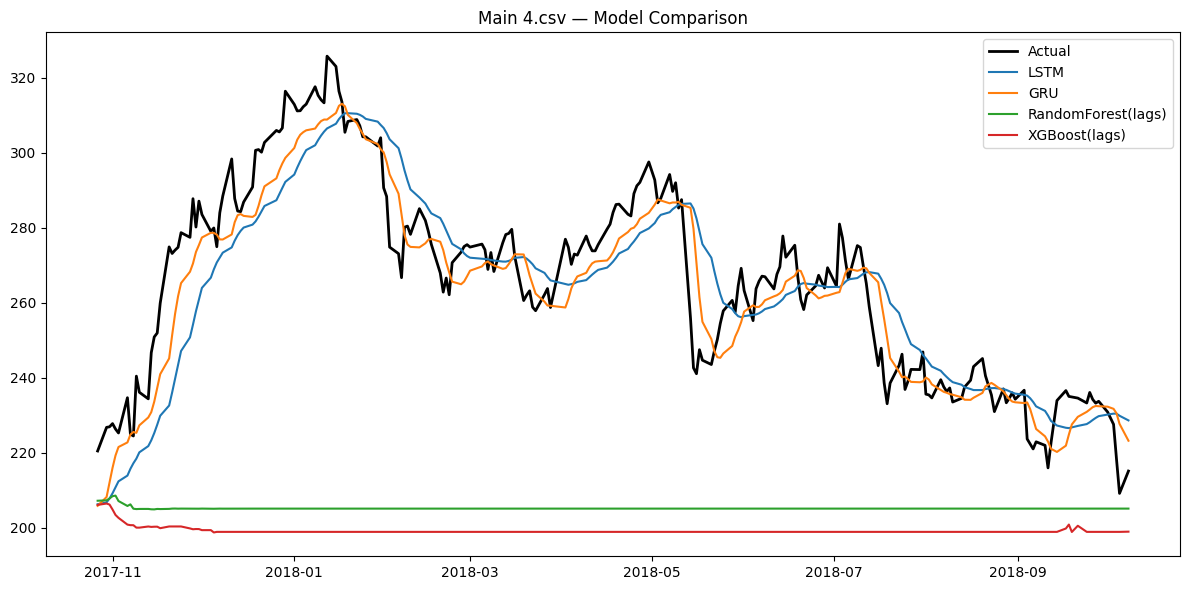


=== Summary (sorted by RMSE) ===
| Model              |    RMSE |     MAE | MAPE   | Directional Acc.   | Notes                                                                 |
|--------------------|---------|---------|--------|--------------------|-----------------------------------------------------------------------|
| Naive (last close) |  5.8586 |  4.2628 | 1.62%  | 49.57%             | Same test window                                                      |
| GRU(64→32), L=60   |  9.6548 |  7.5583 | 2.86%  | 46.15%             | 80/20 split; MinMax scaler; early stopping                            |
| LSTM(50→50), L=60  | 14.1635 | 11.1148 | 4.22%  | 48.29%             | 80/20 split; MinMax scaler; early stopping                            |
| RandomForest(lags) | 65.9284 | 60.4678 | 21.99% | 7.69%              | Lagged close features; standardized inputs; 80/20 chronological split |
| XGBoost(lags)      | 71.5363 | 66.4566 | 24.26% | 7.69%              | Lagged close features; 

In [ ]:
# dataset4_four_models_compare.py
# Extends your LSTM with GRU + RandomForest(lags) + XGBoost(lags)/GBR and unified metrics/plot

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (12, 6)

# -------------------- Config --------------------
CSV_PATH   = "/content/Main 4.csv"
DATE_COL   = "Date"
CLOSE_COL  = "Close"
LOOKBACK   = 60
EPOCHS     = 20      # keep modest and enable early stopping for fairness
BATCH_SIZE = 64
PATIENCE   = 5
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# -------------------- Metrics helpers --------------------
def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[m], y_pred[m]
    rmse = float(np.sqrt(np.mean((yt - yp)**2)))
    mae  = float(np.mean(np.abs(yt - yp)))
    denom = np.clip(np.abs(yt), 1e-8, None)
    mape = float(100.0 * np.mean(np.abs((yt - yp) / denom)))
    if yt.size >= 2:
        true_dir = np.sign(yt[1:] - yt[:-1])
        pred_dir = np.sign(yp[1:] - yp[:-1])
        da = float(100.0 * np.mean(true_dir == pred_dir))
    else:
        da = np.nan
    return rmse, mae, mape, da  # [attached_file:1]

def print_metrics_table(model_name, y_true, y_pred, notes=""):
    rmse, mae, mape, da = compute_regression_metrics(y_true, y_pred)
    df_tbl = pd.DataFrame([{
        "Model": model_name,
        "RMSE": f"{rmse:.4f}",
        "MAE": f"{mae:.4f}",
        "MAPE": f"{mape:.2f}%",
        "Directional Acc.": f"{da:.2f}%" if np.isfinite(da) else "N/A",
        "Notes": notes
    }])
    try:
        import tabulate
        print(tabulate.tabulate(df_tbl, headers="keys", tablefmt="github", showindex=False))
    except Exception:
        print(df_tbl.to_markdown(index=False))
    return df_tbl  # [attached_file:1]

# -------------------- Data loading --------------------
def load_csv(path, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path, parse_dates=[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    if close_col not in df.columns:
        # try case-insensitive match
        cols_lower = {c.lower(): c for c in df.columns}
        if 'close' in cols_lower:
            df = df.rename(columns={cols_lower['close']: close_col})
        else:
            raise ValueError("Close column not found.")
    return df  # [attached_file:1]

# -------------------- Sequence data maker --------------------
def create_seq_dataset(series_scaled, time_step):
    X, y = [], []
    for i in range(len(series_scaled) - time_step):
        X.append(series_scaled[i:(i+time_step), 0])
        y.append(series_scaled[i + time_step, 0])
    return np.array(X), np.array(y)  # [attached_file:1]

# -------------------- Sequence models --------------------
def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        LSTM(50, return_sequences=False),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model  # [attached_file:1]

def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dense(16),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model  # [attached_file:1]

def train_eval_sequence(series, lookback, builder, label, epochs=EPOCHS, batch_size=BATCH_SIZE):
    scaler = MinMaxScaler((0,1))
    scaled = scaler.fit_transform(series.reshape(-1,1))
    split_idx = int(len(scaled) * 0.8)

    train_data = scaled[:split_idx]
    test_data  = scaled[split_idx - lookback:]  # include lookback overlap

    X_train, y_train = create_seq_dataset(train_data, lookback)
    X_test,  y_test  = create_seq_dataset(test_data,  lookback)

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

    es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    model = builder((lookback,1))
    model.fit(X_train, y_train, validation_split=0.1, epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[es])

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).reshape(-1)
    actual = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

    return {"name": label, "actual": actual, "pred": pred}  # [attached_file:1]

# -------------------- Lagged tabular models --------------------
def build_lagged_matrix(series_vals, lags=60):
    y = pd.Series(series_vals.reshape(-1), name='y')
    df = pd.DataFrame({'y': y})
    for L in range(1, lags+1):
        df[f'lag_{L}'] = df['y'].shift(L)
    df = df.dropna().reset_index(drop=True)
    X = df.drop(columns=['y']).values
    y = df['y'].values
    return X, y  # [attached_file:1]

def train_eval_tabular(series_vals, lags=60):
    X_all, y_all = build_lagged_matrix(series_vals, lags=lags)
    split = int(0.8 * len(X_all))
    X_train_raw, X_test_raw = X_all[:split], X_all[split:]
    y_train, y_test = y_all[:split], y_all[split:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)

    rows = []

    rf = RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    rows.append(("RandomForest(lags)", pred_rf, "Lagged close features; standardized inputs"))  # [attached_file:1]

    if HAS_XGB:
        xgb = XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            random_state=RANDOM_SEED, tree_method="hist"
        )
        xgb.fit(X_train, y_train, verbose=False)
        pred_xgb = xgb.predict(X_test)
        rows.append(("XGBoost(lags)", pred_xgb, "Lagged close features; standardized inputs"))  # [attached_file:1]
    else:
        gbr = GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3, random_state=RANDOM_SEED
        )
        gbr.fit(X_train, y_train)
        pred_gbr = gbr.predict(X_test)
        rows.append(("GradientBoosting(lags)", pred_gbr, "Lagged close features; standardized inputs"))  # [attached_file:1]

    return y_test, rows  # [attached_file:1]

# -------------------- Baseline --------------------
def naive_last_close_baseline(y_true):
    if len(y_true) < 2:
        return np.array([])
    return np.concatenate([[y_true[0]], y_true[:-1]])  # [attached_file:1]

# -------------------- Main --------------------
def main():
    df = load_csv(CSV_PATH, date_col=DATE_COL, close_col=CLOSE_COL)
    dates = df[DATE_COL].values
    close_vals = df[CLOSE_COL].astype(float).values

    # Sequence models
    res_lstm = train_eval_sequence(close_vals, LOOKBACK, build_lstm, label=f"LSTM(50→50), L={LOOKBACK}", epochs=EPOCHS, batch_size=BATCH_SIZE)
    res_gru  = train_eval_sequence(close_vals, LOOKBACK, build_gru,  label=f"GRU(64→32), L={LOOKBACK}", epochs=EPOCHS, batch_size=BATCH_SIZE)

    # Tabular models
    y_test_tab, tab_models = train_eval_tabular(close_vals, lags=LOOKBACK)

    # Align comparable test window length (tail-align)
    n_seq = len(res_lstm["actual"])
    n_tab = len(y_test_tab)
    n = min(n_seq, n_tab)

    def tail(v): return v[-n:]
    actual_common = tail(res_lstm["actual"])

    # Build unified metrics + plot
    fig, ax = plt.subplots()
    ax.plot(tail(dates)[-n:], actual_common, label='Actual', color='black', linewidth=2)

    rows = []

    lstm_pred_common = tail(res_lstm["pred"])
    rows.append(print_metrics_table(res_lstm["name"], actual_common, lstm_pred_common,
                                    notes="80/20 split; MinMax scaler; early stopping"))  # [attached_file:1]
    ax.plot(tail(dates)[-n:], lstm_pred_common, label='LSTM')

    gru_pred_common = tail(res_gru["pred"])
    rows.append(print_metrics_table(res_gru["name"], actual_common, gru_pred_common,
                                    notes="80/20 split; MinMax scaler; early stopping"))  # [attached_file:1]
    ax.plot(tail(dates)[-n:], gru_pred_common, label='GRU')

    for name, pred_tab, note in tab_models:
        pred_common = tail(pred_tab)
        rows.append(print_metrics_table(name, actual_common, pred_common,
                                        notes=f"{note}; 80/20 chronological split"))  # [attached_file:1]
        ax.plot(tail(dates)[-n:], pred_common, label=name)

    # Naive on same window
    naive_pred = naive_last_close_baseline(actual_common)
    rows.append(print_metrics_table("Naive (last close)", actual_common, naive_pred,
                                    notes="Same test window"))  # [attached_file:1]

    ax.set_title(f"{os.path.basename(CSV_PATH)} — Model Comparison")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Summary table sorted by RMSE
    summary = pd.concat(rows, ignore_index=True)
    summary2 = summary.copy()
    summary2["RMSE_val"] = summary2["RMSE"].astype(float)
    summary_sorted = summary2.sort_values("RMSE_val").drop(columns=["RMSE_val"])
    try:
        import tabulate
        print("\n=== Summary (sorted by RMSE) ===")
        print(tabulate.tabulate(summary_sorted, headers="keys", tablefmt="github", showindex=False))
    except Exception:
        print(summary_sorted.to_markdown(index=False))

    best_row = summary_sorted.iloc[0]
    print(f"\nBest by RMSE on this dataset: {best_row['Model']} (RMSE={best_row['RMSE']})")
    return summary_sorted  # [attached_file:1]

if __name__ == "__main__":
    main()
